In [3]:
%pip install tensorflow

^C
Note: you may need to restart the kernel to use updated packages.


  Using cached tensorflow-2.18.0-cp311-cp311-win_amd64.whl (7.5 kB)
                                              0.0/390.2 MB ? eta -:--:--
                                              0.0/390.2 MB ? eta -:--:--
                                            0.0/390.2 MB 445.2 kB/s eta 0:14:37
                                            0.0/390.2 MB 445.2 kB/s eta 0:14:37
                                            0.0/390.2 MB 445.2 kB/s eta 0:14:37
                                            0.0/390.2 MB 151.3 kB/s eta 0:42:59
                                            0.1/390.2 MB 218.8 kB/s eta 0:29:44
                                            0.1/390.2 MB 291.5 kB/s eta 0:22:19
                                            0.1/390.2 MB 291.5 kB/s eta 0:22:19
                                            0.1/390.2 MB 291.5 kB/s eta 0:22:19
                                            0.1/390.2 MB 257.8 kB/s eta 0:25:14
                                            0.2/390.2 MB 338.5 kB/

ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\himan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\cli\base_command.py", line 169, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "c:\Users\himan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\cli\req_command.py", line 248, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\himan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\commands\install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "c:\Users\himan\AppData\Local\Programs\Python\Python311\Lib\site-packages\pip\_internal\resolution\resolvelib\resolver.py", line 92, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "c:\Users\himan\AppData\Local\Programs\Python\Python311\Lib\site

In [12]:
import tensorflow as tf
import matplotlib.pyplot as plt

In [13]:
import os
print("Current Dir ",os.getcwd())
current_dir = os.getcwd()
train_path = os.path.join(current_dir,"dataset","Train")
test_path = os.path.join(current_dir,"dataset","Test")
valid_path = os.path.join(current_dir,"dataset","Valid")


Current Dir  d:\Internship\Potato_Diseases_Detection


In [14]:
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels = "inferred",
    label_mode = "categorical",
    color_mode = "rgb",
    image_size = (128,128),
    shuffle = True,
    interpolation = "bilinear",
)

Found 900 files belonging to 3 classes.


In [15]:
training_set.class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [16]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels = "inferred",
    label_mode = "categorical",
    color_mode = "rgb",
    image_size = (128,128),
    shuffle = True,
    interpolation = "bilinear",
)

Found 300 files belonging to 3 classes.


In [17]:
cnn = tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size = 3,padding="same",activation="relu",input_shape = [128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size = 3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size = 3,padding="same",activation="relu"))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size = 3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size = 3,padding="same",activation="relu"))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size = 3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size = 3,padding="same",activation="relu"))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size = 3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size = 3,padding="same",activation="relu"))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size = 3,activation="relu"))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Dropout(0.25))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(units=1500,activation="relu"))
cnn.add(tf.keras.layers.Dropout(0.4))

cnn.add(tf.keras.layers.Dense(units=3,activation="softmax"))

c:\Users\himan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         4,503 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,790,227 (29.72 MB)

 Trainable params: 7,790,227 (29.72 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


29/29 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.3818 - loss: 1.9758 - val_accuracy: 0.4800 - val_loss: 0.9306
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 947ms/step - accuracy: 0.6264 - loss: 0.8247 - val_accuracy: 0.6533 - val_loss: 0.6590
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 939ms/step - accuracy: 0.6981 - loss: 0.6131 - val_accuracy: 0.7667 - val_loss: 0.5245
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.7593 - loss: 0.5657 - val_accuracy: 0.7700 - val_loss: 0.5173
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8119 - loss: 0.4260 - val_accuracy: 0.7867 - val_loss: 0.4537
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8534 - loss: 0.3734 - val_accuracy: 0.9133 - val_loss: 0.2045
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.8954 - loss: 0.2541 - val_accuracy: 0.9367 - val_loss: 0.1662
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.9255 - loss: 0.1925 - val_accuracy: 0.9100 - val_loss: 0.21

In [21]:
train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.9269 - loss: 0.1888
Training accuracy: 0.9244444370269775


In [22]:
val_loss ,val_acc = cnn.evaluate(validation_set)
print("Validation accuration : ",val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - accuracy: 0.9189 - loss: 0.2186
Validation accuration :  0.9166666865348816


In [23]:
cnn.save('trained_plant_disease_model.keras')

In [24]:
training_history.history

{'accuracy': [0.4422222077846527,
  0.6633333563804626,
  0.7388888597488403,
  0.7844444513320923,
  0.8211110830307007,
  0.8788889050483704,
  0.8955555558204651,
  0.9355555772781372,
  0.9555555582046509,
  0.9466666579246521],
 'loss': [1.3865327835083008,
  0.7432432770729065,
  0.5599311590194702,
  0.49368393421173096,
  0.4182793200016022,
  0.3134092092514038,
  0.2506040334701538,
  0.17583785951137543,
  0.11636342853307724,
  0.14318695664405823],
 'val_accuracy': [0.47999998927116394,
  0.653333306312561,
  0.7666666507720947,
  0.7699999809265137,
  0.7866666913032532,
  0.9133333563804626,
  0.9366666674613953,
  0.9100000262260437,
  0.9399999976158142,
  0.9166666865348816],
 'val_loss': [0.9306187033653259,
  0.6590169668197632,
  0.5244800448417664,
  0.5172694325447083,
  0.4537418484687805,
  0.20445646345615387,
  0.1662379950284958,
  0.21290242671966553,
  0.1534637063741684,
  0.22582992911338806]}

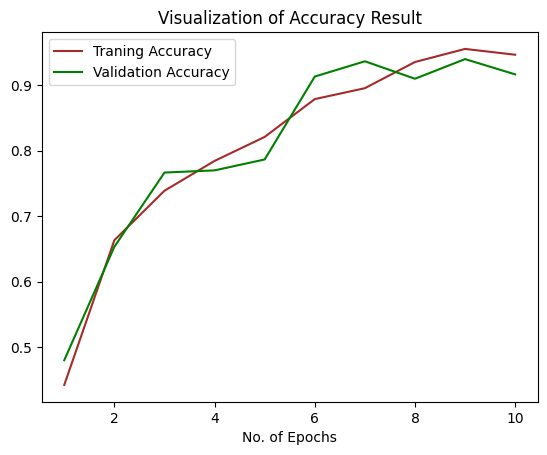

In [27]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color="brown",label="Traning Accuracy")
plt.plot(epochs,training_history.history['val_accuracy'],color="green",label="Validation Accuracy")
plt.xlabel("No. of Epochs")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()